# Run matched filters in PRISMA product

**Author**: Gonzalo Mateo-García

See example of using PRISMA reader in [georeader](https://spaceml-org.github.io/georeader/simultaneous_prisma_emit/).

The Window-Wide Matched Filter is proposed in:
>  J. Roger, L. Guanter, J. Gorroño, and I. Irakulis-Loitxate, “Exploiting the entire near-infrared spectral range to improve the detection of methane plumes with high-resolution imaging spectrometers,” Atmospheric Measurement Techniques, vol. 17, no. 4, pp. 1333–1346, Feb. 2024, doi: [10.5194/amt-17-1333-2024](https://doi.org/10.5194/amt-17-1333-2024).

```
pip install marshsi adlfs
```

## Download PRISMA image from UNEP IMEO Cloud Storage


In [1]:
import os

# Azure credentials for the UNEP IMEO container. Set these as environment
# variables (or GitHub Actions secrets) so the integration tests can download
# the data in CI; leave them unset to use a file already in tests/data/.
SAS_TOKEN = os.environ.get("SAS_TOKEN", "")
AZURE_STORAGE_ACCOUNT = os.environ.get("AZURE_STORAGE_ACCOUNT", "")
CONTAINER = os.environ.get("CONTAINER_NAME", "")

folder_dest = "../tests/data/PRISMA"
tile = "PRS_L1_STD_OFFL_20250316071846_20250316071850_0001"
path_raster_dst = os.path.join(folder_dest, f"{tile}.he5")

NEED_DOWNLOAD = not os.path.exists(path_raster_dst)
print(f"File '{path_raster_dst}' exists: {not NEED_DOWNLOAD}")

File '../tests/data/PRISMA/PRS_L1_STD_OFFL_20250316071846_20250316071850_0001.he5' exists: True


In [2]:
if NEED_DOWNLOAD:
    import adlfs
    fs = adlfs.AzureBlobFileSystem(account_name=AZURE_STORAGE_ACCOUNT, sas_token=SAS_TOKEN, container=CONTAINER)

In [3]:
if NEED_DOWNLOAD:
    os.makedirs(folder_dest, exist_ok=True)

    path_raster = f"az://{CONTAINER}/PRISMA/raster/{tile}.he5"
    if not fs.exists(path_raster):
        raise FileNotFoundError(f"File {path_raster} does not exist")
    
    print(f"Downloading {path_raster}...")
    fs.get(path_raster, path_raster_dst)
else:
    print(f"Skipping download, '{path_raster_dst}' already exists")

Skipping download, '../tests/data/PRISMA/PRS_L1_STD_OFFL_20250316071846_20250316071850_0001.he5' already exists


In [4]:
!tree {folder_dest}

../tests/data/PRISMA
├── PRS_L1_STD_OFFL_20250316071846_20250316071850_0001.he5
└── PRS_L1_STD_OFFL_20251007075454_20251007075458_0001.he5

0 directories, 2 files


## Load image

In [5]:
from georeader.readers import prisma

rst = prisma.PRISMA(path_raster_dst)
rst


        File: ../tests/data/PRISMA/PRS_L1_STD_OFFL_20250316071846_20250316071850_0001.he5
        Bounds: (53.92854309082031, 38.101470947265625, 54.339393615722656, 38.42490768432617)
        Time: 2025-03-16 07:18:46.598999+00:00
        VNIR Range: (np.float32(406.9934), np.float32(977.3654)) 63 bands
        SWIR Range: (np.float32(943.3579), np.float32(2497.1155)) 171 bands
        

## Run WW-MF retrieval on PRISMA product

Run wide matched filter retrieval based on the work of [Roger et al. 2024](https://doi.org/10.5194/amt-17-1333-2024).

In [6]:
from marshsi.prismaenmap import retrieval_upv_prisma_enmap

cube_crs = retrieval_upv_prisma_enmap.MF_sunglint_combo_prisma(rst)
cube_crs

INFO:marshsi.prismaenmap.retrieval_upv_prisma_enmap:Running WMF in wavelength range: 978.68798828125 - 2462.7236328125


INFO:marshsi.prismaenmap.retrieval_upv_prisma_enmap:Running MF2100 in wavelength range: 2102.565673828125 - 2462.7236328125


 
         Transform: | 30.00, 0.00, 230898.88|
| 0.00,-30.00, 4257208.59|
| 0.00, 0.00, 1.00|
         Shape: (7, 1221, 1223)
         Resolution: (30.0, 30.0)
         Bounds: (230898.877003546, 4220578.5899621155, 267588.877003546, 4257208.5899621155)
         CRS: EPSG:32640
         fill_value_default: -1
        

In [7]:
rgb_local = rst.load_rgb(as_reflectance=True, raw=False)
rgb_local

/home/gonzalo/git/UNEP_IMEO_MARS/marshsi/.venv/lib/python3.12/site-packages/georeader/reflectance.py:219: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  response = np.divide(response, response.sum(axis=0), where=response.sum(axis=0) > 0)# (N, K)


 
         Transform: | 30.00, 0.00, 230898.88|
| 0.00,-30.00, 4257208.59|
| 0.00, 0.00, 1.00|
         Shape: (3, 1221, 1223)
         Resolution: (30.0, 30.0)
         Bounds: (230898.877003546, 4220578.5899621155, 267588.877003546, 4257208.5899621155)
         CRS: EPSG:32640
         fill_value_default: -1
        

## Plot results

<>:8: SyntaxWarning: invalid escape sequence '\D'
<>:10: SyntaxWarning: invalid escape sequence '\D'
<>:8: SyntaxWarning: invalid escape sequence '\D'
<>:10: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_98966/2047996446.py:8: SyntaxWarning: invalid escape sequence '\D'
  plot.show(mf, ax=ax[1], vmin=0, vmax=.3, title= "MF $\Delta X$CH$_4$ [ppm]", mask=True, add_colorbar_next_to=True)
/tmp/ipykernel_98966/2047996446.py:10: SyntaxWarning: invalid escape sequence '\D'
  plot.show(wmf, ax=ax[2], vmin=0, vmax=.3, title= "WWMF $\Delta X$CH$_4$ [ppm]", mask=True,add_colorbar_next_to=True)


<Axes: title={'center': 'WWMF $\\Delta X$CH$_4$ [ppm]'}>

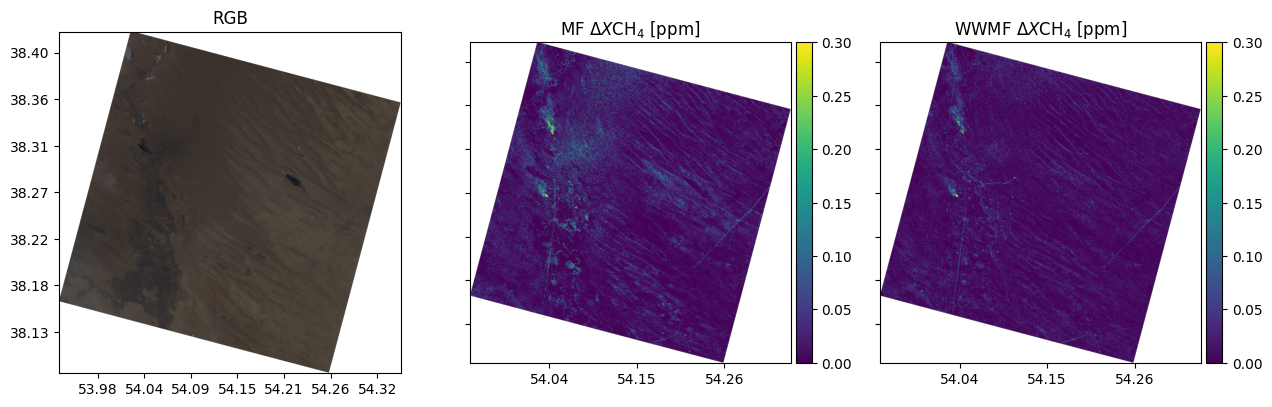

In [8]:
from georeader import plot
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,3, figsize=(15,5), sharey=True)
plot.show(rgb_local, ax=ax[0], mask=True, title="RGB")

mf = cube_crs.isel({"band": 1})
plot.show(mf, ax=ax[1], vmin=0, vmax=.3, title= "MF $\Delta X$CH$_4$ [ppm]", mask=True, add_colorbar_next_to=True)
wmf = cube_crs.isel({"band": 2})
plot.show(wmf, ax=ax[2], vmin=0, vmax=.3, title= "WWMF $\Delta X$CH$_4$ [ppm]", mask=True,add_colorbar_next_to=True)

## Plume vetting

Plume vetting is a spectral validation step that checks whether the pixels inside each detected plume actually show the CH₄ absorption signature relative to nearby background pixels. 

The method is described in:

> C. Xiang, D. R. Thompson, R. O. Green, J. E. Fahlen, A. K. Thorpe, P. G. Brodrick,
> R. W. Coleman, A. M. Lopez, and C. D. Elder, *Identification of false methane plumes
> for orbital imaging spectrometers: A case study with EMIT*,
> Remote Sensing of Environment, 2025.
> <https://www.sciencedirect.com/science/article/pii/S0034425725002640>

In [9]:
import geopandas as gpd
import pandas as pd
import numpy as np
from georeader.geotensor import GeoTensor
from marshsi.quantification import ATMOSPHERE_HEIGHT_METHANE
from marshsi.plume_vetting import compute_prisma, plot_vetting

PLUMES_FILE = "../tests/data/plume_vetting/plumes_prisma.gpkg"
plumes_gdf = gpd.read_file(PLUMES_FILE)
polygons = [geom.geoms[0] for geom in plumes_gdf.geometry]

# Convert WMF from ppm → ppm·m (multiply by effective column height in metres)
wmf_values = wmf.values
if wmf_values.ndim == 3:
    wmf_values = wmf_values[0]
wmf_arr = np.where(
    wmf_values == wmf.fill_value_default,
    wmf.fill_value_default,
    wmf_values * ATMOSPHERE_HEIGHT_METHANE,
)
wmf_arr = np.where(~np.isfinite(wmf_arr), wmf.fill_value_default, wmf_arr)

wmf_ppmxm = GeoTensor(wmf_arr, transform=wmf.transform, crs=wmf.crs,
                      fill_value_default=wmf.fill_value_default)

results = compute_prisma(
    pi=rst,
    cmf=wmf_ppmxm,
    polygons=polygons,
    min_polygon_size=20,
    random_seed=42,
)

summary = (
    pd.DataFrame.from_dict(results, orient="index")
    .reindex(columns=["D_norm", "alpha_con_len"])
    .rename_axis("polygon")
    .sort_index()
)
summary

,D_norm,alpha_con_len
polygon,,
0,0.674556,5.261158e+02
1,0.999934,2.142866e-06
2,0.595000,1.513098e+03
3,0.199131,4.043991e+03
4,0.999859,1.796295e-08
5,0.999977,1.440377e-08
6,1.000012,1.292974e-07
7,0.863818,3.920611e+02
8,0.887058,3.509868e+02


Polygon 10: D_norm=0.172


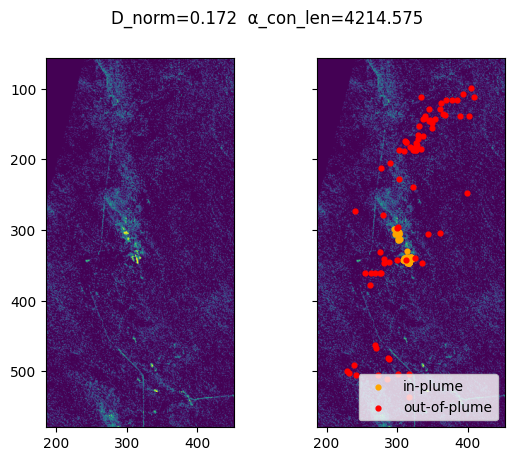

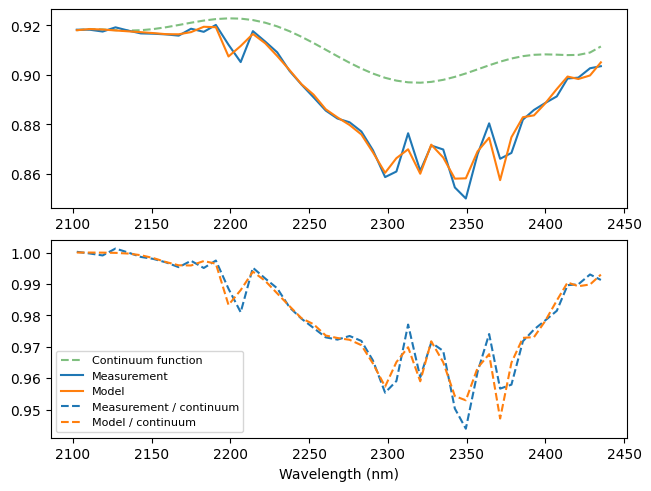

In [10]:
if results:
    best_idx = min(results, key=lambda k: results[k]["D_norm"])
    print(f"Polygon {best_idx}: D_norm={results[best_idx]['D_norm']:.3f}")
    plot_vetting(results[best_idx], cmf_values=wmf_ppmxm.values)

The marshsi package and tutorials are released under a [Creative Commons non-commercial Share-Alike licence](https://creativecommons.org/licenses/by-nc-sa/4.0/legalcode.txt). For using the codes in comercial pipelines written consent by the authors must be provided.

 If you find this work useful please cite:

```
@Article{roger_2024,
    AUTHOR = {Roger, J. and Guanter, L. and Gorroño, J. and Irakulis-Loitxate, I.},
    TITLE = {Exploiting the entire near-infrared spectral range to improve the detection of methane plumes with high-resolution imaging spectrometers},
    JOURNAL = {Atmospheric Measurement Techniques},
    VOLUME = {17},
    YEAR = {2024},
    NUMBER = {4},
    PAGES = {1333--1346},
    URL = {https://amt.copernicus.org/articles/17/1333/2024/},
    DOI = {10.5194/amt-17-1333-2024}
}
```